# 05 Comparer les modèles à base d’arbres

Nous allons enfin **prédire notre score de compromis résistance–ductilité** à partir de la composition et des paramètres de soudage.

Nous comparons un arbre de décision, du bagging et une forêt aléatoire. Nous testons plusieurs hyperparamètres, puis retenons la configuration avec la plus faible erreur de validation. Une prédiction constante sert de référence : un modèle doit faire mieux que cette solution simple.

Nous avançons dans cet ordre : charger les données, préparer la validation, tester les arbres, tester le bagging, tester les forêts, comparer les résultats et évaluer le modèle retenu sur le test final.

Notre cible est continue : nous utilisons les versions **Regressor**, pas les Classifier. Nous gardons notre cible et la préparation de départ fixées pour comparer les familles d’arbres dans les mêmes conditions. Il n’y a pas d’ACP ici : les arbres n’en ont pas besoin, et les variables originales facilitent leur interprétation.

## 1 Reprendre les entrées et la séparation

Nous repartons des entrées **non imputées** du notebook 02. Nous n’utilisons pas directement le tableau déjà préparé sur tout le développement, car chaque apprentissage de validation doit avoir sa propre préparation.

Nous reprenons les groupes et la partition existants : 539 lignes de développement et 127 réservées au test. UTS et allongement restent exclus des entrées ; ils servent uniquement à calculer les réponses attendues.

In [1]:
from pathlib import Path
import json, time, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'outputs/05'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
print('Version de scikit-learn :', sklearn_version)
pd.set_option('display.max_colwidth', None)

Version de scikit-learn : 1.9.1


In [2]:
categories = ['AC_DC', 'Electrode_pol', 'WeldType']
source = ROOT / 'outputs/02/dataset_traction.csv'
donnees = pd.read_csv(source, index_col='row_id',
    dtype={c: str for c in categories + ['WeldID', 'partition']},
    keep_default_na=False, na_values=[''], float_precision='round_trip')
schema = json.loads((ROOT / 'data/processed/welddb_metadata.json').read_text())['schema']
variables_X = schema['COMPOSITION'] + schema['PROCESS']
mesures = ['UTS_MPa', 'Elongation_pct']
X = donnees[variables_X]
Y = donnees[mesures]
groupes = donnees['groupe']
dev = donnees['partition'].eq('developpement')
test = donnees['partition'].eq('test')
assert (dev | test).all()
assert set(groupes[dev]).isdisjoint(set(groupes[test]))
X_dev, Y_dev, G_dev = X.loc[dev], Y.loc[dev], groupes.loc[dev]
print(f'{len(X_dev)} lignes de développement ; {int(test.sum())} réservées au test.')
assert not set(variables_X) & set(mesures + ['score_compromis', 'WeldID', 'groupe'])

539 lignes de développement ; 127 réservées au test.


## 2 Fixer les règles de comparaison

Nous utilisons **cinq plis par groupes**. Dans chaque pli, nous apprenons sur quatre parties et prédisons la cinquième. Les essais d’un même groupe restent ensemble. Toutes les configurations utilisent les mêmes plis.

Nous refaisons deux calculs dans chaque apprentissage :
- la préparation de X : seuil de remplissage de 25 %, médiane et encodage ;
- les rangs UTS/allongement qui définissent y, comme dans le notebook 02.

Nous ne standardisons pas les nombres : les arbres ne nécessitent pas cette transformation.

Nous donnons un poids total égal à chaque groupe pour l’apprentissage. Un groupe avec plusieurs essais ne doit pas dominer simplement parce qu’il a plus de lignes. Le bootstrap des ensembles reste celui proposé par scikit-learn ; nous ne réalisons pas un bootstrap personnalisé de dépôts.

Nous n’utilisons pas l’erreur OOB pour choisir les modèles : elle ne garantit pas que les autres lignes du même dépôt soient absentes de l’apprentissage. La validation par groupes reste notre référence.

In [3]:
def poids_groupes(g):
    return (1 / g.map(g.value_counts())).to_numpy(dtype=float)

def calculer_cible(Y_apprentissage, groupes_apprentissage, Y_a_transformer):
    poids = poids_groupes(groupes_apprentissage)
    rangs = pd.DataFrame(index=Y_a_transformer.index)
    for mesure in mesures:
        tableau = pd.DataFrame({'valeur': Y_apprentissage[mesure].to_numpy(), 'poids': poids})
        masse = tableau.groupby('valeur')['poids'].sum()
        reference = (masse.cumsum() - masse / 2) / masse.sum()
        rangs[mesure] = np.interp(Y_a_transformer[mesure], masse.index, reference)
    return np.sqrt(rangs.prod(axis=1))

In [4]:
def creer_preparation(X_apprentissage):
    taux = X_apprentissage.notna().mean()
    gardees = taux[taux >= 0.25].index.tolist()
    numeriques = [c for c in gardees if c not in categories]
    categorielles = [c for c in gardees if c in categories]
    return ColumnTransformer([
        ('nombres', SimpleImputer(strategy='median'), numeriques),
        ('categories', Pipeline([
            ('manquants', SimpleImputer(strategy='constant', fill_value='manquant')),
            ('encodage', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorielles)
    ])

### Choisir les métriques

Nous classons les configurations selon la **RMSE avec un poids égal par groupe**. Elle est la racine de l’erreur quadratique moyenne : plus elle est faible, mieux c’est. Le poids égal par groupe évite que les dépôts les plus répétés dominent l’évaluation.

Nous affichons aussi la MAE (erreur absolue moyenne), le R² et la RMSE par ligne. Un R² négatif signifie que les prédictions sont moins bonnes que la moyenne des réponses de validation pour cette métrique ; ce n’est pas un pourcentage de réussite.

Les erreurs sont exprimées dans l’unité du score, pas en MPa. La dispersion des cinq erreurs de validation renseigne sur la variation entre plis, pas sur un intervalle de confiance ni sur une preuve de supériorité statistique.

In [5]:
def mesurer(y_reel, prediction, g):
    poids = poids_groupes(g)
    return {
        'RMSE_groupes': np.sqrt(mean_squared_error(y_reel, prediction, sample_weight=poids)),
        'MAE_groupes': mean_absolute_error(y_reel, prediction, sample_weight=poids),
        'R2_groupes': r2_score(y_reel, prediction, sample_weight=poids),
        'RMSE_lignes': np.sqrt(mean_squared_error(y_reel, prediction))
    }

### Préparer les cinq séparations

Nous conservons les entrées non transformées. Pour chaque configuration, une pipeline enchaîne la préparation et le modèle. Elle apprend les médianes et les catégories uniquement sur les lignes d’apprentissage.

Les rangs de la cible sont calculés séparément, uniquement sur cet apprentissage. Un cache temporaire évite de refaire une préparation identique : il accélère les calculs sans mélanger les plis.

In [6]:
import tempfile
cache = tempfile.TemporaryDirectory(prefix='soudures_pipeline_')

def creer_pipeline(X_apprentissage, modele):
    # Le choix des colonnes utilise uniquement cet apprentissage.
    return Pipeline([
        ('preparation', creer_preparation(X_apprentissage)),
        ('modele', clone(modele))
    ], memory=cache.name)

plis = []
validation = GroupKFold(n_splits=5)
for train, val in validation.split(X_dev, groups=G_dev):
    ids_train, ids_val = X_dev.index[train], X_dev.index[val]
    assert set(groupes.loc[ids_train]).isdisjoint(set(groupes.loc[ids_val]))
    plis.append({
        'X_train': X.loc[ids_train], 'X_val': X.loc[ids_val],
        'y_train': calculer_cible(Y.loc[ids_train], groupes.loc[ids_train], Y.loc[ids_train]),
        'y_val': calculer_cible(Y.loc[ids_train], groupes.loc[ids_train], Y.loc[ids_val]),
        'g_train': groupes.loc[ids_train], 'g_val': groupes.loc[ids_val]
    })
print('5 plis par groupes ; entrées conservées sans imputation préalable.')

5 plis par groupes ; entrées conservées sans imputation préalable.


## 3 Une recherche en deux étapes

Pour l’arbre seul, nous essayons toutes les combinaisons proposées.

Pour le bagging et la forêt :
1. Nous comparons les autres réglages avec **100 arbres**.
2. Nous gardons les **trois meilleurs réglages** et l’ancien meilleur réglage, puis testons **50, 100, 250 et 500 arbres**.

Nous choisissons la plus petite RMSE moyenne sur les cinq plis. Nous ne cherchons pas un coude à tout prix : la courbe indique si ajouter des arbres apporte encore un gain. Cette recherche réduit les calculs, mais peut manquer un réglage éliminé à la première étape.

La boucle est écrite explicitement pour recalculer notre cible dans chaque pli. Le test n’intervient jamais dans cette sélection.

In [7]:
details_plis = []

def tester_grille(nom, modele, grille, etape='grille'):
    lignes = []
    configurations = list(ParameterGrid(grille))
    for numero, parametres in enumerate(configurations):
        erreurs = []
        debut = time.perf_counter()
        for pli, d in enumerate(plis, start=1):
            pipeline = creer_pipeline(d['X_train'], modele)
            pipeline.set_params(**{'modele__' + k: v for k, v in parametres.items()})
            pipeline.fit(d['X_train'], d['y_train'],
                         modele__sample_weight=poids_groupes(d['g_train']))
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', message='Found unknown categories.*', category=UserWarning)
                prediction = pipeline.predict(d['X_val'])
            scores = mesurer(d['y_val'], prediction, d['g_val'])
            scores['RMSE_apprentissage'] = mesurer(
                d['y_train'], pipeline.predict(d['X_train']), d['g_train'])['RMSE_groupes']
            erreurs.append(scores)
            details_plis.append({'modele': nom, 'etape': etape,
                                 'configuration': numero, 'pli': pli, **scores})
        tableau = pd.DataFrame(erreurs)
        lignes.append({'modele': nom, 'etape': etape, 'configuration': numero,
                       'parametres': parametres, **tableau.mean().to_dict(),
                       'ecart_type_RMSE': tableau['RMSE_groupes'].std(ddof=1),
                       'temps_secondes': time.perf_counter() - debut})
        if (numero + 1) % 20 == 0:
            print(f'{nom} — {etape} : {numero + 1}/{len(configurations)} configurations.', flush=True)
    resultats = pd.DataFrame(lignes).sort_values('RMSE_groupes', kind='stable')
    print(f'{nom} — {etape} : {len(resultats)} configurations sur 5 plis.')
    display(resultats[['parametres', 'RMSE_groupes', 'ecart_type_RMSE',
                      'RMSE_apprentissage']].head(5).round(4))
    return resultats

def affiner_nombre_arbres(nom, modele, premiers_resultats, ancien_reglage):
    candidats = premiers_resultats.head(3)['parametres'].tolist() + [ancien_reglage]
    deja_testes = [p for p in premiers_resultats['parametres']]
    nouvelles_grilles = []
    for candidat in candidats:
        for nombre in [50, 100, 250, 500]:
            params = {**candidat, 'n_estimators': nombre}
            if params not in deja_testes:
                nouvelles_grilles.append({k: [v] for k, v in params.items()})
                deja_testes.append(params)
    suite = tester_grille(nom, modele, nouvelles_grilles, etape='nombre d’arbres')
    return pd.concat([premiers_resultats, suite], ignore_index=True).sort_values(
        'RMSE_groupes', kind='stable')

## 4 Une référence très simple

Avant les arbres, nous prédisons la moyenne des scores d’apprentissage, pondérée par groupe. Si les modèles ne font pas mieux, ils n’apportent pas d’amélioration utile à notre tâche.

In [8]:
reference = tester_grille('Moyenne constante', DummyRegressor(strategy='mean'), {})

Moyenne constante — grille : 1 configurations sur 5 plis.


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
0,{},0.1495,0.0169,0.149


## 5 Arbre de décision

Nous testons **192 combinaisons** : profondeur 2, 3, 4, 6, 8, 12, 20 ou sans limite ; minimum 1, 2, 5, 10, 15 ou 20 lignes par feuille ; minimum 2, 5, 10 ou 20 lignes pour diviser un nœud.

Une profondeur limitée ou des feuilles plus grandes peuvent réduire le surapprentissage. Le graphique suivant compare l’erreur d’apprentissage et celle de validation.

In [9]:
grille_arbre = {
    'max_depth': [2, 3, 4, 6, 8, 12, 20, None],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}
arbres = tester_grille('Arbre', DecisionTreeRegressor(random_state=SEED), grille_arbre)

Arbre — grille : 20/192 configurations.
Arbre — grille : 40/192 configurations.
Arbre — grille : 60/192 configurations.
Arbre — grille : 80/192 configurations.
Arbre — grille : 100/192 configurations.
Arbre — grille : 120/192 configurations.
Arbre — grille : 140/192 configurations.
Arbre — grille : 160/192 configurations.
Arbre — grille : 180/192 configurations.
Arbre — grille : 192 configurations sur 5 plis.


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
116,"{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 2}",0.1263,0.0075,0.1055
117,"{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 5}",0.1263,0.0075,0.1055
118,"{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 10}",0.1263,0.0075,0.1055
119,"{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 20}",0.1263,0.0075,0.1055
140,"{'max_depth': 12, 'min_samples_leaf': 20, 'min_samples_split': 2}",0.1264,0.0075,0.1054


### Visualiser l’effet de la profondeur

Pour lire facilement le graphique, nous montrons les configurations avec `min_samples_leaf=1` et `min_samples_split=2`. Nous comparons les erreurs d’apprentissage et de validation, sans modifier les choix après lecture du test.

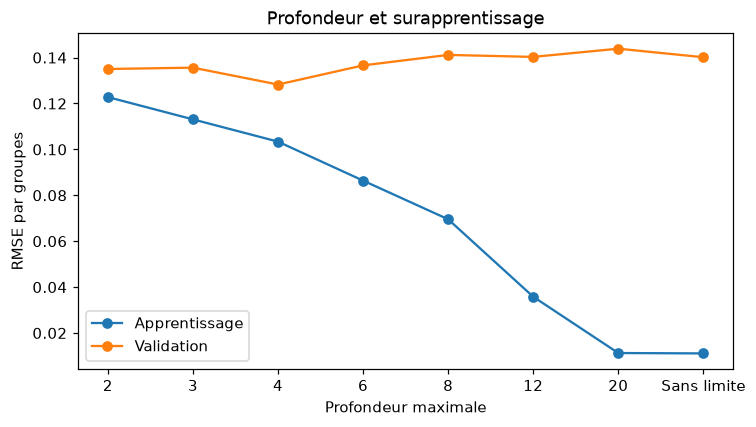

In [10]:
courbe = arbres[arbres['parametres'].apply(
    lambda p: p['min_samples_leaf'] == 1 and p['min_samples_split'] == 2)].copy()
courbe['profondeur'] = courbe['parametres'].apply(lambda p: p['max_depth'])
courbe = courbe.sort_values('profondeur', na_position='last')
labels = ['Sans limite' if pd.isna(v) else str(int(v)) for v in courbe['profondeur']]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, courbe['RMSE_apprentissage'], marker='o', label='Apprentissage')
ax.plot(labels, courbe['RMSE_groupes'], marker='o', label='Validation')
ax.set(xlabel='Profondeur maximale', ylabel='RMSE par groupes', title='Profondeur et surapprentissage')
ax.legend(); fig.tight_layout()
fig.savefig(OUT / 'profondeur_arbre.png', dpi=150); plt.show()

## 6 Bagging

Nous faisons la moyenne de plusieurs arbres entraînés sur des tirages avec remise.

À 100 arbres, nous testons une taille de tirage de **50 %, 65 %, 80 % ou 100 %**, et **1, 2, 5 ou 10 lignes minimum par feuille** : 16 combinaisons. Nous affinons ensuite le nombre d’arbres pour les meilleurs réglages.

La profondeur reste sans limite. Chaque arbre utilise toutes les variables. La taille du tirage n’est pas une séparation apprentissage/test.

In [11]:
modele_bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=SEED),
    bootstrap=True, max_features=1.0, random_state=SEED, n_jobs=1)
grille_bagging = {
    'n_estimators': [100],
    'max_samples': [0.5, 0.65, 0.8, 1.0],
    'estimator__min_samples_leaf': [1, 2, 5, 10]
}
bagging_initial = tester_grille('Bagging', modele_bagging, grille_bagging, etape='réglages à 100 arbres')
bagging = affiner_nombre_arbres('Bagging', modele_bagging, bagging_initial,
    {'n_estimators': 250, 'max_samples': 1.0, 'estimator__min_samples_leaf': 1})

Bagging — réglages à 100 arbres : 16 configurations sur 5 plis.
Bagging — nombre d’arbres : 9 configurations sur 5 plis.


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
3,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 100}",0.1089,0.0121,0.0473
7,"{'estimator__min_samples_leaf': 2, 'max_samples': 1.0, 'n_estimators': 100}",0.1091,0.0130,0.0559
2,"{'estimator__min_samples_leaf': 1, 'max_samples': 0.8, 'n_estimators': 100}",0.1094,0.0110,0.0554
1,"{'estimator__min_samples_leaf': 1, 'max_samples': 0.65, 'n_estimators': 100}",0.1095,0.0108,0.0630
6,"{'estimator__min_samples_leaf': 2, 'max_samples': 0.8, 'n_estimators': 100}",0.1099,0.0126,0.0628


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
2,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 500}",0.1078,0.0123,0.0464
8,"{'estimator__min_samples_leaf': 1, 'max_samples': 0.8, 'n_estimators': 500}",0.1082,0.0108,0.0544
1,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 250}",0.1082,0.0120,0.0467
5,"{'estimator__min_samples_leaf': 2, 'max_samples': 1.0, 'n_estimators': 500}",0.1084,0.0128,0.0553
4,"{'estimator__min_samples_leaf': 2, 'max_samples': 1.0, 'n_estimators': 250}",0.1088,0.0129,0.0555


## 7 Forêt aléatoire

La forêt ajoute au bootstrap un tirage des variables candidates à chaque division.

À 100 arbres, nous testons une profondeur de **4, 6, 8, 12, 20 ou sans limite**, **1, 2, 5 ou 10 lignes minimum par feuille**, et **25 %, 50 %, 75 % ou 100 % des variables candidates** : 96 combinaisons. Nous affinons ensuite le nombre d’arbres comme pour le bagging.

In [12]:
modele_foret = RandomForestRegressor(bootstrap=True, random_state=SEED, n_jobs=1)
grille_foret = {
    'n_estimators': [100],
    'max_depth': [4, 6, 8, 12, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [0.25, 0.5, 0.75, 1.0]
}
forets_initial = tester_grille('Forêt aléatoire', modele_foret, grille_foret, etape='réglages à 100 arbres')
forets = affiner_nombre_arbres('Forêt aléatoire', modele_foret, forets_initial,
    {'n_estimators': 250, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5})

Forêt aléatoire — réglages à 100 arbres : 20/96 configurations.
Forêt aléatoire — réglages à 100 arbres : 40/96 configurations.
Forêt aléatoire — réglages à 100 arbres : 60/96 configurations.
Forêt aléatoire — réglages à 100 arbres : 80/96 configurations.
Forêt aléatoire — réglages à 100 arbres : 96 configurations sur 5 plis.
Forêt aléatoire — nombre d’arbres : 9 configurations sur 5 plis.


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
64,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}",0.1044,0.0108,0.0352
80,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}",0.1046,0.0105,0.0349
84,"{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}",0.1060,0.0104,0.0348
81,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 2, 'n_estimators': 100}",0.1062,0.0101,0.0530
65,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 2, 'n_estimators': 100}",0.1062,0.0101,0.0530


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage
2,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}",0.1038,0.0105,0.0346
1,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 250}",0.1039,0.0104,0.0346
5,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}",0.1039,0.0103,0.0343
4,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 250}",0.1040,0.0105,0.0343
8,"{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}",0.1053,0.0106,0.0344


## 8 Comparer les meilleures configurations

Nous retenons la plus petite RMSE moyenne de validation dans chaque famille. Le test ne sert pas à choisir. Les barres d’erreur montrent la variation entre les plis ; elles ne prouvent pas qu’un modèle est toujours supérieur.

La forêt obtient 0,1038, le bagging 0,1078 et l’arbre seul 0,1263. Les deux ensembles font nettement mieux que la référence constante (0,1495). La forêt et le bagging restent proches.

In [13]:
tous_resultats = pd.concat([reference, arbres, bagging, forets], ignore_index=True)
comparaison = pd.concat([t.head(1) for t in [reference, arbres, bagging, forets]], ignore_index=True)
comparaison = comparaison.sort_values('RMSE_groupes', kind='stable').reset_index(drop=True)
display(comparaison[['modele', 'parametres', 'RMSE_groupes', 'ecart_type_RMSE',
                    'MAE_groupes', 'R2_groupes', 'RMSE_lignes', 'RMSE_apprentissage']].round(4))

meilleur = comparaison.iloc[0]
print('Modèle retenu par validation :', meilleur['modele'])
print('Hyperparamètres :', meilleur['parametres'])

Modèle retenu par validation : Forêt aléatoire
Hyperparamètres : {'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}


,modele,parametres,RMSE_groupes,ecart_type_RMSE,MAE_groupes,R2_groupes,RMSE_lignes,RMSE_apprentissage
0,Forêt aléatoire,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}",0.1038,0.0105,0.0787,0.5099,0.1043,0.0346
1,Bagging,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 500}",0.1078,0.0123,0.0811,0.4732,0.1080,0.0464
2,Arbre,"{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 2}",0.1263,0.0075,0.0979,0.2665,0.1264,0.1055
3,Moyenne constante,{},0.1495,0.0169,0.1183,-0.0116,0.1460,0.1490


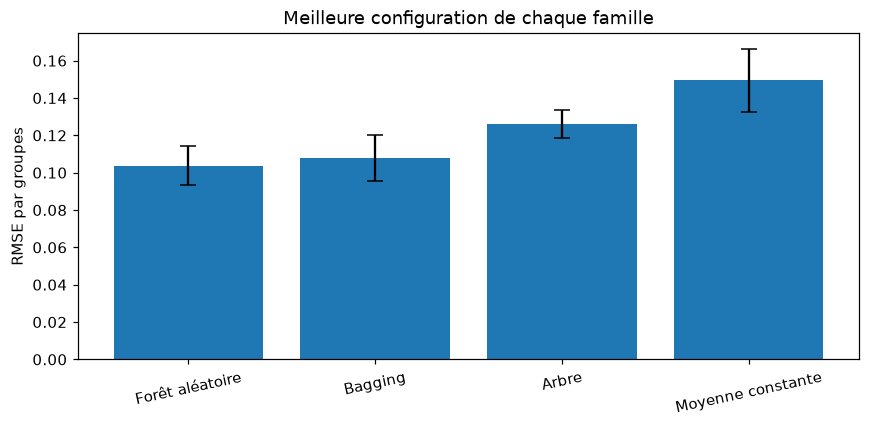

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparaison['modele'], comparaison['RMSE_groupes'],
       yerr=comparaison['ecart_type_RMSE'], capsize=5)
ax.set(ylabel='RMSE par groupes', title='Meilleure configuration de chaque famille')
ax.tick_params(axis='x', rotation=12)
fig.tight_layout(); fig.savefig(OUT / 'comparaison_validation.png', dpi=150); plt.show()

### Lire la courbe du nombre d’arbres

Nous gardons les autres paramètres fixes pour isoler l’effet du nombre d’arbres. Pour la forêt retenue, l’erreur diminue surtout entre 50 et 100 arbres, puis la courbe s’aplatit. Passer de 250 à 500 apporte moins de 0,0001 de RMSE.

Notre règle du minimum retient 500 arbres. Si le temps de calcul devient une contrainte, 250 constitue un compromis proche ; nous ne changeons pas le choix après lecture du test.

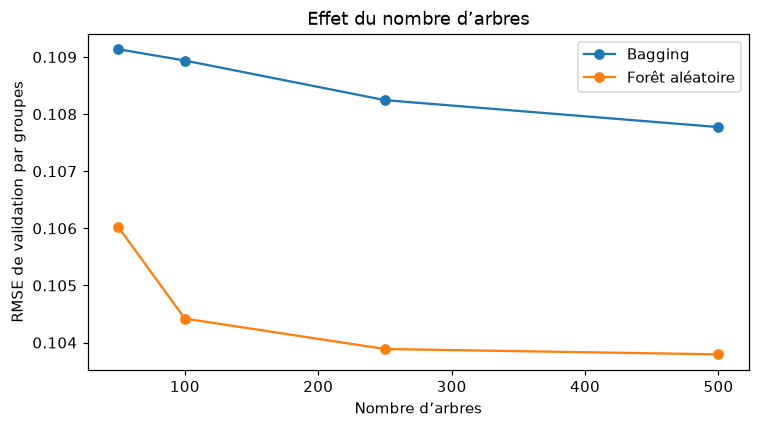

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
for nom, tableau in [('Bagging', bagging), ('Forêt aléatoire', forets)]:
    params = tableau.iloc[0]['parametres']
    autres = {k: v for k, v in params.items() if k != 'n_estimators'}
    selection = tableau[tableau['parametres'].apply(lambda p: all(p[k] == v for k, v in autres.items()))].copy()
    selection['nombre_arbres'] = selection['parametres'].apply(lambda p: p['n_estimators'])
    selection = selection.sort_values('nombre_arbres')
    ax.plot(selection['nombre_arbres'], selection['RMSE_groupes'], marker='o', label=nom)
ax.set(xlabel='Nombre d’arbres', ylabel='RMSE de validation par groupes', title='Effet du nombre d’arbres')
ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'nombre_arbres.png', dpi=150); plt.show()

## 9 Réentraîner et comprendre le meilleur arbre simple

Nous réentraînons le meilleur arbre simple sur tout le développement pour afficher ses premières règles. L’illustration est limitée aux trois premiers niveaux pour rester lisible ; elle ne réduit pas l’arbre entraîné.

Cette visualisation aide à comprendre le fonctionnement d’un arbre. Elle ne prouve pas qu’une intervention sur une variable aura l’effet prédit, ni que cet arbre simple est le meilleur des ensembles.

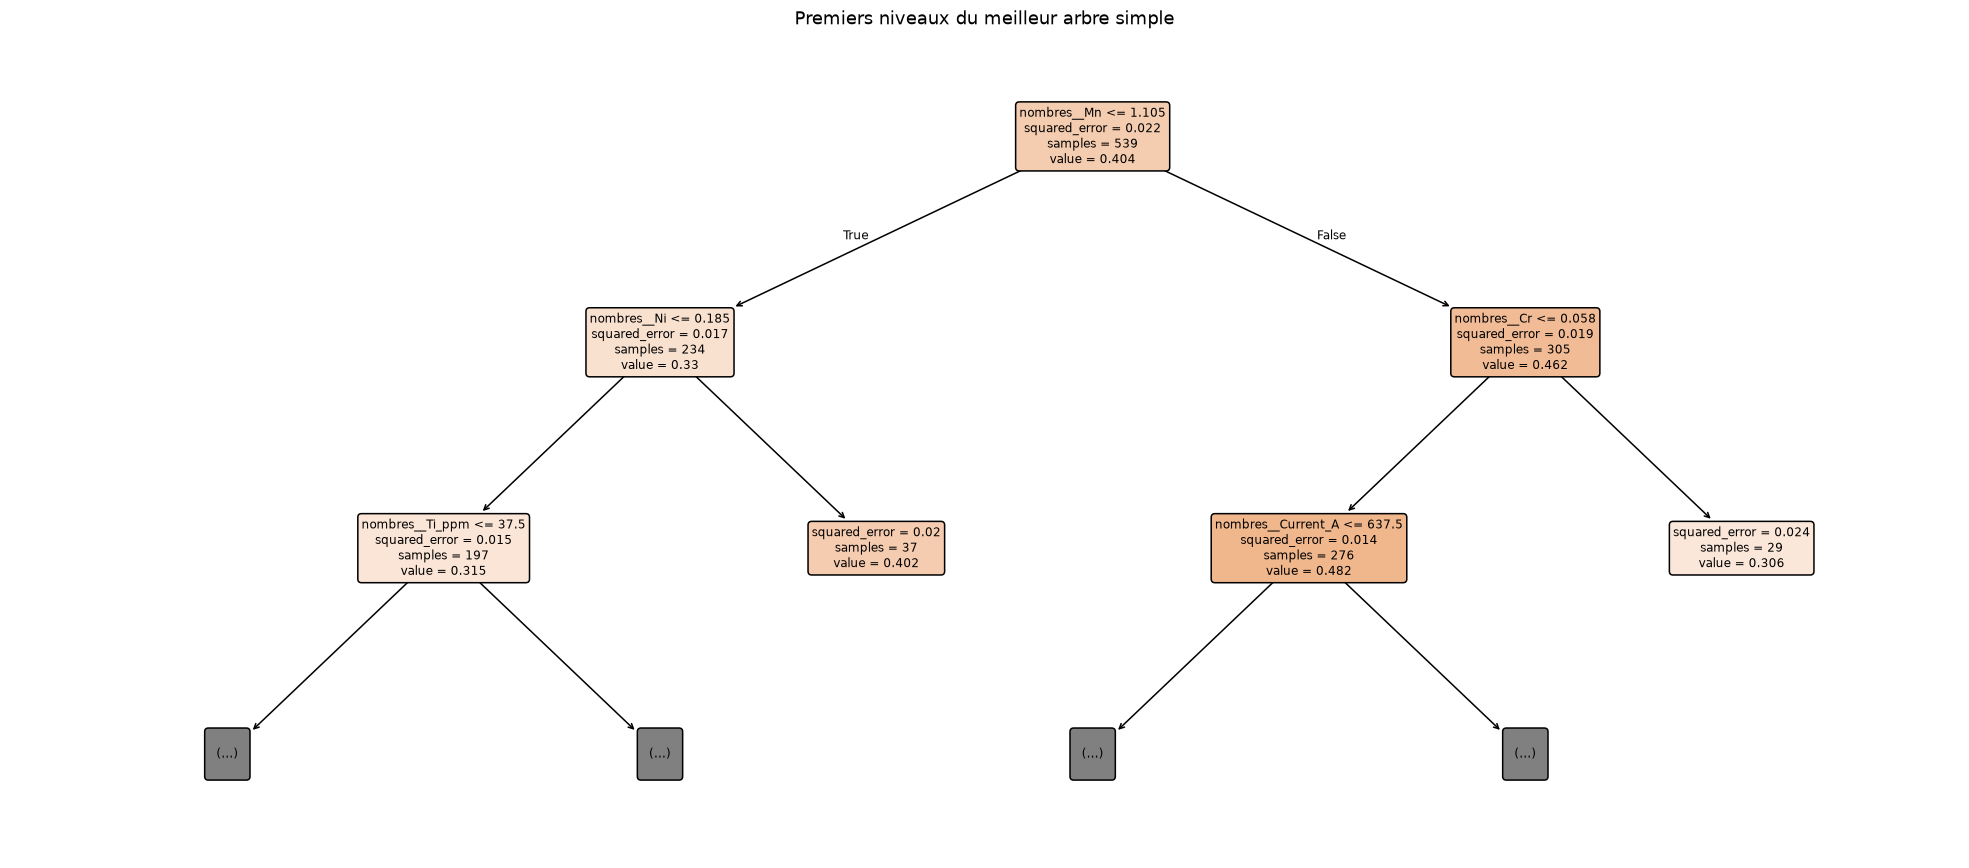

In [16]:
y_dev_final = calculer_cible(Y_dev, G_dev, Y_dev)
np.testing.assert_allclose(y_dev_final, donnees.loc[dev, 'score_compromis'], atol=1e-12)
arbre_pipeline = creer_pipeline(X_dev, DecisionTreeRegressor(
    random_state=SEED, **arbres.iloc[0]['parametres']))
arbre_pipeline.fit(X_dev, y_dev_final, modele__sample_weight=poids_groupes(G_dev))
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbre_pipeline.named_steps['modele'],
          feature_names=arbre_pipeline.named_steps['preparation'].get_feature_names_out(),
          max_depth=2, filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Premiers niveaux du meilleur arbre simple')
fig.tight_layout(); fig.savefig(OUT / 'regles_arbre.png', dpi=150); plt.show()

## 10 Évaluer le modèle retenu

Nous réentraînons la pipeline retenue sur les 539 lignes de développement, puis prédisons les 127 lignes du test avec `predict`.

Ce test a déjà été consulté lors de notre première recherche. Nous pouvons y évaluer le nouveau modèle, mais le résultat n’est pas une nouvelle évaluation indépendante. Aucun réglage n’a été choisi en fonction de ce test.

In [17]:
modeles = {'Moyenne constante': DummyRegressor(strategy='mean'),
           'Arbre': DecisionTreeRegressor(random_state=SEED),
           'Bagging': modele_bagging, 'Forêt aléatoire': modele_foret}
modele_choisi = clone(modeles[meilleur['modele']]).set_params(**meilleur['parametres'])
modele_final = creer_pipeline(X_dev, modele_choisi)
modele_final.fit(X_dev, y_dev_final, modele__sample_weight=poids_groupes(G_dev))
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Found unknown categories.*', category=UserWarning)
    prediction_test = modele_final.predict(X.loc[test])
y_test_final = calculer_cible(Y_dev, G_dev, Y.loc[test])
np.testing.assert_allclose(y_test_final, donnees.loc[test, 'score_compromis'], atol=1e-12)
resultat_test = mesurer(y_test_final, prediction_test, groupes.loc[test])
reference_finale = creer_pipeline(X_dev, DummyRegressor(strategy='mean'))
reference_finale.fit(X_dev, y_dev_final, modele__sample_weight=poids_groupes(G_dev))
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Found unknown categories.*', category=UserWarning)
    prediction_reference = reference_finale.predict(X.loc[test])
resultat_reference = mesurer(y_test_final, prediction_reference, groupes.loc[test])
display(pd.DataFrame({meilleur['modele']: resultat_test,
                      'Moyenne constante': resultat_reference}).T.round(4))

,RMSE_groupes,MAE_groupes,R2_groupes,RMSE_lignes
Forêt aléatoire,0.0916,0.068,0.6002,0.0882
Moyenne constante,0.1475,0.118,-0.0366,0.1441


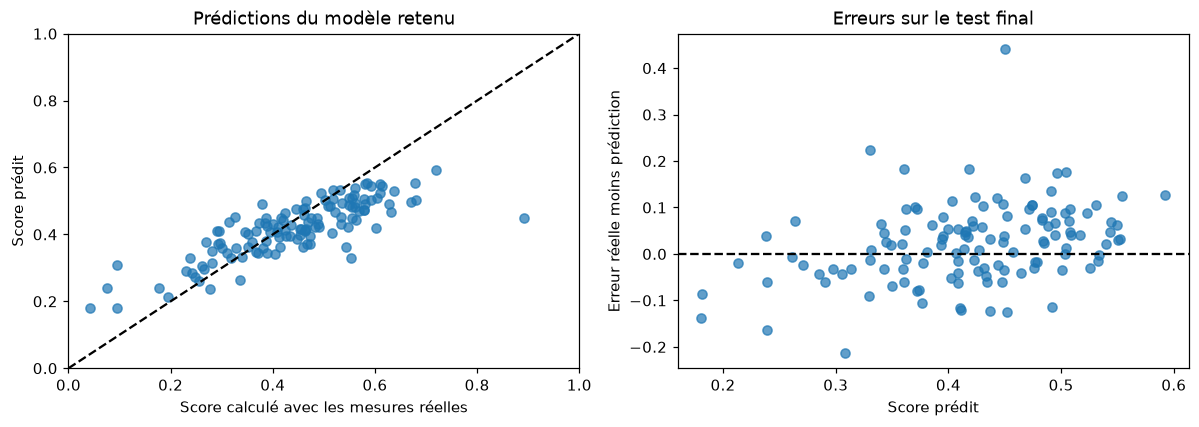

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test_final, prediction_test, alpha=0.7)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0].set(xlabel='Score calculé avec les mesures réelles', ylabel='Score prédit',
            title='Prédictions du modèle retenu', xlim=(0, 1), ylim=(0, 1))
axes[1].scatter(prediction_test, y_test_final - prediction_test, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set(xlabel='Score prédit', ylabel='Erreur réelle moins prédiction', title='Erreurs sur le test final')
fig.tight_layout(); fig.savefig(OUT / 'predictions_test.png', dpi=150); plt.show()

## 11 Enregistrer le bilan

Nous sauvegardons toutes les configurations, les résultats par pli, le classement des meilleures configurations et les prédictions finales. Le bilan conserve les hyperparamètres et la version utilisée pour pouvoir retrouver l’expérience.

Le modèle qui arrive premier est le meilleur **parmi nos configurations testées, pour notre cible et notre protocole**. Nous n’avons pas comparé toutes les méthodes de ML ni toutes les préparations possibles.

In [19]:
tous_resultats.to_csv(OUT / 'toutes_configurations.csv', index=False)
pd.DataFrame(details_plis).to_csv(OUT / 'resultats_par_pli.csv', index=False)
comparaison.to_csv(OUT / 'comparaison_validation.csv', index=False)
pd.DataFrame({'groupe': groupes.loc[test], 'y_reel': y_test_final,
              'prediction': prediction_test, 'reference': prediction_reference}).to_csv(
                  OUT / 'predictions_test.csv', index_label='row_id')

def convertir(obj):
    if isinstance(obj, np.generic): return obj.item()
    raise TypeError(type(obj).__name__)

bilan = {'modele_retenu': meilleur['modele'], 'hyperparametres': meilleur['parametres'],
         'RMSE_validation_groupes': float(meilleur['RMSE_groupes']),
         'test_modele_retenu': resultat_test, 'test_reference': resultat_reference,
         'regle_selection': 'plus petite moyenne des 5 RMSE par groupes sur développement',
         'seed': SEED, 'sklearn': sklearn_version,
         'recherche': 'deux étapes ; 3 meilleurs réglages à 100 arbres et ancien meilleur, puis 50/100/250/500 arbres',
         'nombre_configurations_modeles': len(tous_resultats) - len(reference),
         'test_deja_consulte': True, 'pipeline_complete': True,
         'sha256_dataset': hashlib.sha256(source.read_bytes()).hexdigest(),
         'dev_row_ids': X_dev.index.tolist(), 'test_row_ids': X.loc[test].index.tolist()}
(OUT / 'bilan.json').write_text(json.dumps(bilan, ensure_ascii=False, indent=2, default=convertir))
print(f"Modèle retenu : {meilleur['modele']} ; RMSE validation = {meilleur['RMSE_groupes']:.4f}.")
print('Hyperparamètres :', meilleur['parametres'])
print(f"Test final : RMSE par groupes = {resultat_test['RMSE_groupes']:.4f} ; MAE = {resultat_test['MAE_groupes']:.4f} ; R² = {resultat_test['R2_groupes']:.4f}.")

Modèle retenu : Forêt aléatoire ; RMSE validation = 0.1038.
Hyperparamètres : {'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}
Test final : RMSE par groupes = 0.0916 ; MAE = 0.0680 ; R² = 0.6002.


## Conclusion

Nous avons évalué **322 configurations de modèles**, plus la référence constante, sur cinq plis par groupes. Chaque modèle utilise une pipeline complète : préparation des entrées, puis prédiction.

| Famille | Meilleurs paramètres testés | RMSE de validation |
|---|---|---:|
| Arbre | Profondeur 8 ; minimum 20 lignes par feuille ; minimum 2 pour diviser un nœud | 0,1263 |
| Bagging | 500 arbres ; taille de tirage 100 % avec remise ; minimum 1 ligne par feuille | 0,1078 |
| Forêt | 500 arbres ; profondeur 20 ; minimum 1 ligne par feuille ; 25 % des variables candidates à chaque division | **0,1038** |

**Nous retenons la forêt**, selon la plus petite erreur de validation. Son avantage sur le bagging reste faible, et 500 arbres apporte très peu par rapport à 250.

Sur le test déjà consulté, sa RMSE vaut **0,0916**, sa MAE **0,0680** et son R² **0,6002**. La référence constante obtient une RMSE de 0,1475. C’est encourageant : le modèle améliore nettement la référence, mais ses prédictions restent imparfaites. Le R² n’est pas un pourcentage de prédictions correctes.

L’ancienne forêt obtenait 0,1057 en validation et 0,0940 sur le test : l’amélioration est modeste. Les nouveaux réglages ont été choisis sur la validation ; le test réutilisé n’est pas une nouvelle évaluation indépendante.

Cette conclusion concerne notre score résistance–allongement et les 666 lignes disponibles. La recherche en deux étapes réduit les calculs, sans garantir l’optimum d’une grille exhaustive. Les groupes de Jules sont une approximation de l’identité des soudures.
